# Embedded Leverage Empirical Checks

This notebook reads the locally generated replication data and runs compact empirical checks for Frazzini-Pedersen embedded leverage.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path.cwd()
DATA = BASE / 'data'
RESULTS = BASE / 'results'
INDEX_DATA = DATA / 'index_options'
INDEX_RESULTS = RESULTS / 'index_options'
YAHOO_DATA = DATA / 'yahoo_etfs'
YAHOO_RESULTS = RESULTS / 'yahoo_etfs'
FIGURES = BASE / 'figures'
FIGURES.mkdir(exist_ok=True)

def ann_stats(s, periods):
    s = pd.Series(s).dropna()
    return pd.Series({
        'n': len(s),
        'mean_pct': 100 * s.mean(),
        'vol_pct': 100 * s.std(ddof=1),
        'ann_return_pct': 100 * periods * s.mean(),
        'ann_vol_pct': 100 * np.sqrt(periods) * s.std(ddof=1),
        'ann_sharpe': np.sqrt(periods) * s.mean() / s.std(ddof=1),
        'positive_pct': 100 * (s > 0).mean(),
        'min_pct': 100 * s.min(),
        'max_pct': 100 * s.max(),
    })


## ETF BAB

In [2]:
etf_results = pd.read_csv(YAHOO_RESULTS / 'etf_bab_results_2017_2025_paper_method.csv', parse_dates=['date'])
etf_results['date'] = pd.to_datetime(etf_results['date'])
etf_daily = etf_results[etf_results['level'].eq('portfolio')].copy()
etf_pairs = etf_results[etf_results['level'].eq('pair')].copy()

etf_summary_cols = {'after_fee': 'bab_ret_after_fee', 'before_fee': 'bab_ret_before_fee'}
display(pd.concat({k: ann_stats(etf_daily[v], 252) for k, v in etf_summary_cols.items()}, axis=1))
display(etf_pairs.groupby('index_name')['bab_ret'].apply(lambda x: ann_stats(x, 252)['ann_sharpe']).sort_values(ascending=False).to_frame('ann_sharpe'))


,after_fee,before_fee
n,2261.000000,2261.000000
mean_pct,0.003098,0.001957
vol_pct,0.064841,0.064841
ann_return_pct,0.780701,0.493201
ann_vol_pct,1.029313,1.029313
ann_sharpe,0.758468,0.479155
positive_pct,53.869969,52.675807
min_pct,-0.535708,-0.536849
max_pct,0.664096,0.662955


,ann_sharpe
index_name,
Dow Jones,0.966727
S&P 500,0.966204
Nasdaq 100,0.910127
Russell 2000,0.787497
S&P MidCap 400,0.501219
S&P SmallCap 600,0.142244


## ETF PnL Curves

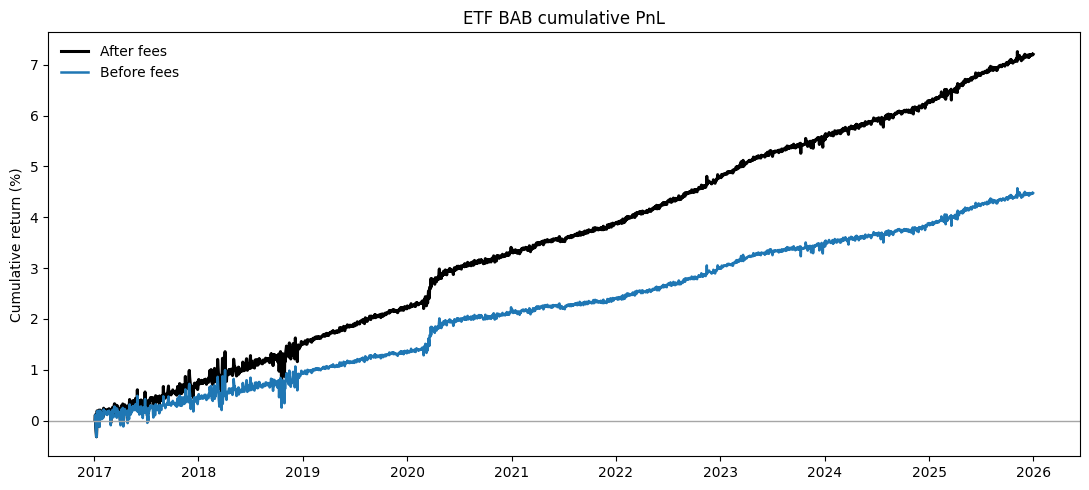

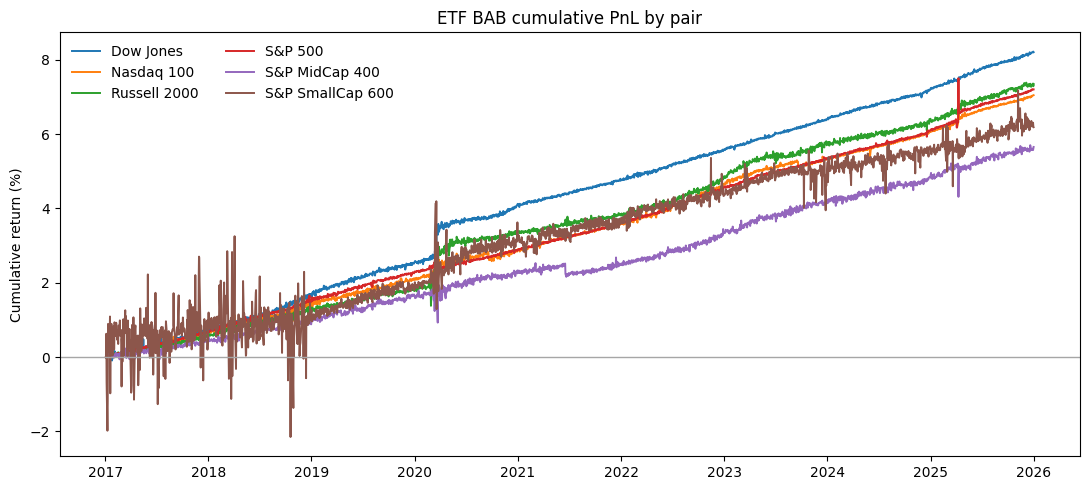

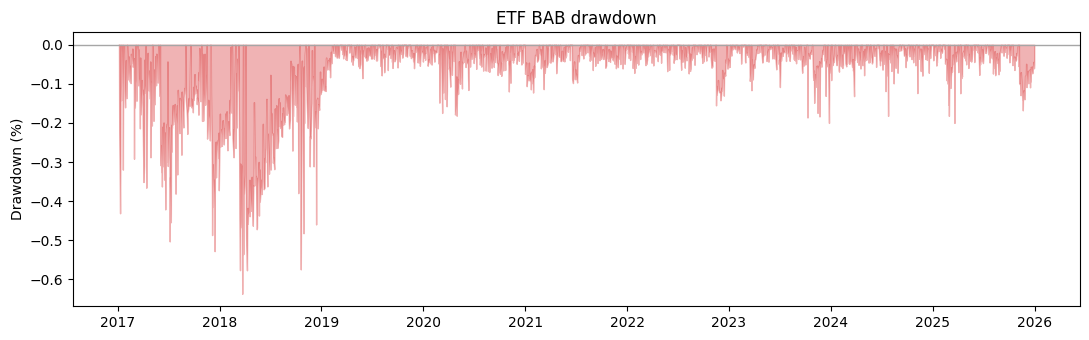

In [3]:
etf_daily = etf_daily.sort_values('date').copy()
etf_daily['cum_pnl'] = (1 + etf_daily['bab_ret_after_fee']).cumprod() - 1
etf_daily['cum_pnl_before_fee'] = (1 + etf_daily['bab_ret_before_fee']).cumprod() - 1
etf_daily['drawdown'] = (1 + etf_daily['cum_pnl']) / (1 + etf_daily['cum_pnl']).cummax() - 1

pair_pnl = (
    etf_pairs.sort_values(['index_name', 'date'])
    .assign(cum_pnl=lambda d: d.groupby('index_name')['bab_ret'].transform(lambda s: (1 + s).cumprod() - 1))
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(etf_daily['date'], 100 * etf_daily['cum_pnl'], color='black', lw=2.2, label='After fees')
ax.plot(etf_daily['date'], 100 * etf_daily['cum_pnl_before_fee'], color='tab:blue', lw=1.8, label='Before fees')
ax.axhline(0, color='0.65', lw=1)
ax.set_title('ETF BAB cumulative PnL')
ax.set_ylabel('Cumulative return (%)')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / 'etf_bab_portfolio_pnl.png', dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
for name, g in pair_pnl.groupby('index_name'):
    ax.plot(g['date'], 100 * g['cum_pnl'], lw=1.4, label=name)
ax.axhline(0, color='0.65', lw=1)
ax.set_title('ETF BAB cumulative PnL by pair')
ax.set_ylabel('Cumulative return (%)')
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig(FIGURES / 'etf_bab_pair_pnl.png', dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.fill_between(etf_daily['date'], 100 * etf_daily['drawdown'], 0, color='tab:red', alpha=0.35)
ax.axhline(0, color='0.65', lw=1)
ax.set_title('ETF BAB drawdown')
ax.set_ylabel('Drawdown (%)')
fig.tight_layout()
fig.savefig(FIGURES / 'etf_bab_drawdown.png', dpi=160)
plt.show()


## Index Option BAB

In [4]:
idx_monthly = pd.read_csv(INDEX_RESULTS / 'index_option_bab_monthly.csv', parse_dates=['entry_date'])
idx_returns = pd.read_parquet(INDEX_DATA / 'index_option_period_returns.parquet')

display(ann_stats(idx_monthly['bab_ret'], 12).to_frame('SPX/NDX option BAB'))
display(idx_monthly.nsmallest(5, 'bab_ret'))


,SPX/NDX option BAB
n,103.000000
mean_pct,-0.190744
vol_pct,2.234975
ann_return_pct,-2.288927
ann_vol_pct,7.742182
ann_sharpe,-0.295644
positive_pct,58.252427
min_pct,-21.264979
max_pct,1.422591


,entry_date,bab_ret,n_underlyings,n_options
37,2020-02-24,-0.212650,2,2303
38,2020-03-23,-0.044784,2,4650
98,2025-03-24,-0.031993,2,6847
63,2022-04-18,-0.018192,2,5162
90,2024-07-22,-0.013215,2,6972


In [5]:
def option_bab_series_from_filter(df):
    rows = []
    for (dt, ticker), g in df.groupby(['entry_date', 'ticker']):
        if len(g) < 4:
            continue
        med = g['omega'].median()
        lo = g[g['omega'] <= med]
        hi = g[g['omega'] > med]
        if len(lo) < 2 or len(hi) < 2:
            continue
        def wa(x, w):
            return np.average(x, weights=w) if len(x) and w.sum() > 0 else np.nan
        rlo, rhi = wa(lo['dh_ret'], lo['option_mkt_cap']), wa(hi['dh_ret'], hi['option_mkt_cap'])
        olo, ohi = wa(lo['omega'], lo['option_mkt_cap']), wa(hi['omega'], hi['option_mkt_cap'])
        if pd.notna(rlo) and pd.notna(rhi) and olo > 0 and ohi > 0:
            rows.append({'entry_date': dt, 'ticker': ticker, 'bab_ret': rlo / olo - rhi / ohi, 'mcap': g['option_mkt_cap'].sum()})
    by = pd.DataFrame(rows)
    monthly = by.groupby('entry_date').apply(lambda x: np.average(x['bab_ret'], weights=x['mcap']), include_groups=False)
    monthly.index = pd.to_datetime(monthly.index)
    return monthly.sort_index()

def option_bab_from_filter(df, name):
    return ann_stats(option_bab_series_from_filter(df), 12).rename(name)

checks = pd.concat([
    option_bab_from_filter(idx_returns, 'all'),
    option_bab_from_filter(idx_returns[idx_returns['abs_delta'].between(.4, .6)], 'ATM'),
    option_bab_from_filter(idx_returns[idx_returns['entry_date'].dt.year != 2020], 'ex-2020'),
], axis=1)
display(checks.T)


,n,mean_pct,vol_pct,ann_return_pct,ann_vol_pct,ann_sharpe,positive_pct,min_pct,max_pct
all,103.0,-0.190744,2.234975,-2.288927,7.742182,-0.295644,58.252427,-21.264979,1.422591
ATM,103.0,0.105351,0.487602,1.264208,1.689102,0.748450,57.281553,-1.538186,1.726009
ex-2020,91.0,0.024192,0.620948,0.290307,2.151026,0.134962,57.142857,-3.199316,1.320307


## Index Option PnL Curves

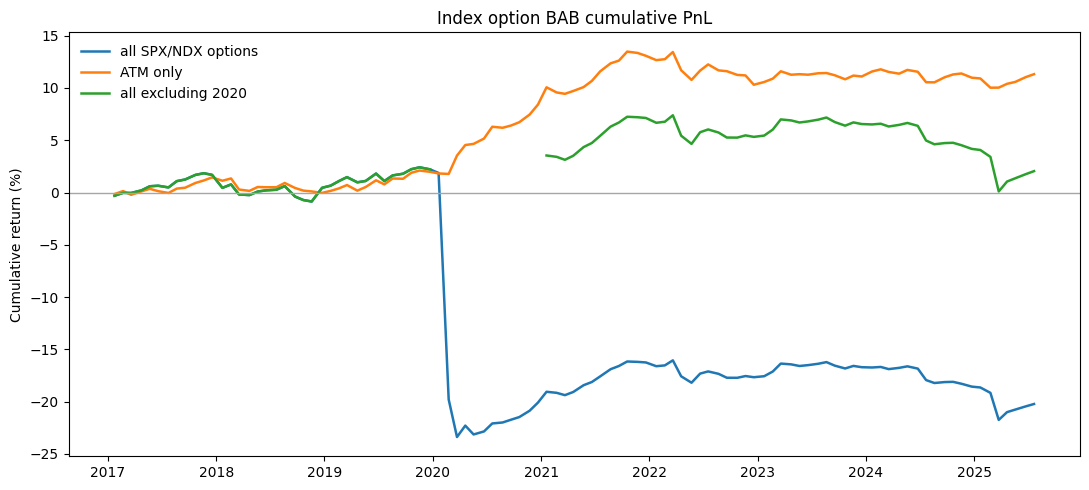

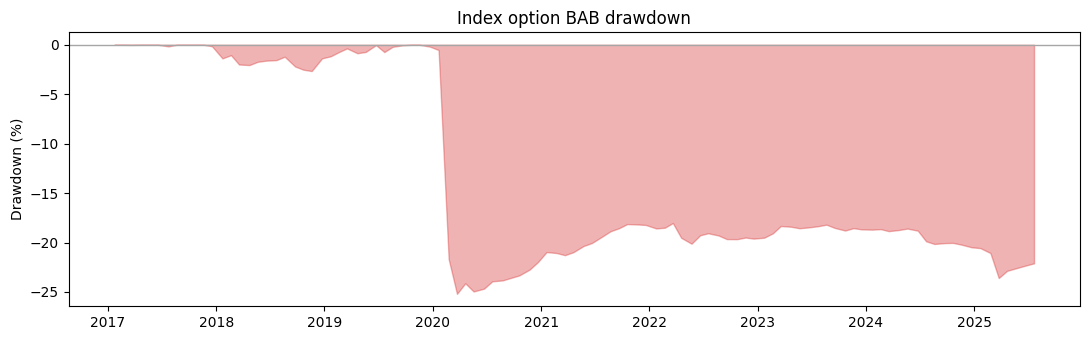

In [6]:
idx_all = idx_monthly.set_index('entry_date')['bab_ret'].sort_index()
idx_atm = option_bab_series_from_filter(idx_returns[idx_returns['abs_delta'].between(.4, .6)])
idx_ex2020 = option_bab_series_from_filter(idx_returns[idx_returns['entry_date'].dt.year != 2020])

curves = pd.DataFrame({
    'all SPX/NDX options': (1 + idx_all).cumprod() - 1,
    'ATM only': (1 + idx_atm).cumprod() - 1,
    'all excluding 2020': (1 + idx_ex2020).cumprod() - 1,
})

fig, ax = plt.subplots(figsize=(11, 5))
for col in curves.columns:
    ax.plot(curves.index, 100 * curves[col], lw=1.8, label=col)
ax.axhline(0, color='0.65', lw=1)
ax.set_title('Index option BAB cumulative PnL')
ax.set_ylabel('Cumulative return (%)')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / 'index_option_bab_pnl.png', dpi=160)
plt.show()

idx_dd = (1 + idx_all).cumprod()
idx_dd = idx_dd / idx_dd.cummax() - 1
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.fill_between(idx_dd.index, 100 * idx_dd, 0, color='tab:red', alpha=0.35)
ax.axhline(0, color='0.65', lw=1)
ax.set_title('Index option BAB drawdown')
ax.set_ylabel('Drawdown (%)')
fig.tight_layout()
fig.savefig(FIGURES / 'index_option_bab_drawdown.png', dpi=160)
plt.show()
